# UAS Pembelajaran Mesin — Heart Disease Risk Prediction

## Soal 1: Problem Definition & Data Acquisition

### 1.1 Problem Statement

Penyakit jantung (*cardiovascular disease*) merupakan salah satu penyebab kematian tertinggi di dunia, dan risikonya sering kali tidak disadari oleh pasien hingga muncul komplikasi serius. Dalam praktiknya, tenaga medis di fasilitas kesehatan primer (puskesmas/klinik) sering menghadapi keterbatasan waktu dan sumber daya untuk melakukan skrining risiko jantung secara mendalam pada setiap pasien. Padahal, deteksi dini terhadap kombinasi gejala klinis (seperti nyeri dada, sesak napas, jantung berdebar) dan faktor risiko gaya hidup (seperti tekanan darah tinggi, diabetes, merokok, obesitas) dapat membantu mempercepat rujukan pasien berisiko tinggi ke pemeriksaan lanjutan.

Proyek ini bertujuan membangun model *machine learning* yang dapat memprediksi risiko penyakit jantung (`Heart_Risk`) seorang individu berdasarkan kombinasi gejala klinis dan faktor risiko yang dapat dikumpulkan secara non-invasif (tanpa pemeriksaan laboratorium mahal), sehingga dapat digunakan sebagai alat bantu skrining awal (*early screening tool*) baik oleh tenaga medis maupun individu secara mandiri melalui aplikasi.

**Tujuan Bisnis/Analisis:**
- Mengidentifikasi individu dengan risiko tinggi penyakit jantung secara cepat berdasarkan data gejala dan faktor risiko yang mudah dikumpulkan (self-report/anamnesis awal).
- Membantu tenaga medis memprioritaskan pasien yang perlu pemeriksaan lanjutan (misalnya EKG atau konsultasi kardiolog).
- Menyediakan alat edukasi risiko kesehatan bagi masyarakat umum melalui aplikasi interaktif.

**Metrik Kesuksesan Proyek:**
Karena konteksnya adalah skrining kesehatan, kesalahan *false negative* (pasien berisiko tinggi diprediksi rendah risiko) jauh lebih berbahaya dibanding *false positive*. Oleh karena itu, metrik utama yang diprioritaskan adalah **Recall** (sensitivitas) pada kelas `Heart_Risk = 1`, didampingi **F1-Score** untuk menjaga keseimbangan dengan Precision, serta **Accuracy** sebagai metrik pendukung. Target: Recall ≥ 90% pada data uji.

### 1.2 Sumber Dataset

- **Nama Dataset:** Heart Disease Risk Prediction Dataset (`heart_disease_risk_dataset_earlymed.csv`)
- **Sumber:** Kaggle — [Heart Disease Risk Prediction Dataset](https://www.kaggle.com/datasets/mahatiratusher/heart-disease-risk-prediction-dataset)
- **Jumlah Data:** 70.000 baris, 19 kolom (17 fitur gejala/faktor risiko biner, 1 fitur numerik `Age`, 1 target `Heart_Risk`)
- **Catatan penting:** Dataset ini bersifat **sintetis** (dibuat secara terprogram, bukan data rekam medis riil), ditandai dengan distribusi target yang seimbang sempurna (35.000 vs 35.000) dan pola hubungan fitur-target yang sangat konsisten. Hal ini perlu disebutkan secara transparan di laporan sebagai batasan (*limitation*) proyek — performa model pada data sintetis kemungkinan lebih tinggi dibanding jika diterapkan pada data klinis riil yang lebih *noisy*.

### 1.3 Statistik Deskriptif Awal

Ditampilkan pada bagian *Informasi Dataset* di bawah (jumlah data, jumlah fitur, tipe data, dan ringkasan statistik).

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heart_disease_risk_dataset_earlymed.csv to heart_disease_risk_dataset_earlymed.csv


Membaca dataset

In [ ]:
df = pd.read_csv("heart_disease_risk_dataset_earlymed.csv")

df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


Informasi Dataset

In [ ]:
print("Jumlah Data :", df.shape[0])
print("Jumlah Fitur :", df.shape[1])

df.info()

Jumlah Data : 70000
Jumlah Fitur : 19
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15

Statistik Deskriptif

In [ ]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


Nama-nama fitur

In [ ]:
df.columns

Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Heart_Risk'],
      dtype='object')

Analisis Kualitas Data

Missing Value

In [ ]:
missing = pd.DataFrame({
    "Missing Value": df.isnull().sum(),
    "Persentase (%)": round(df.isnull().mean()*100,2)
})

missing

,Missing Value,Persentase (%)
Chest_Pain,0,0.0
Shortness_of_Breath,0,0.0
Fatigue,0,0.0
Palpitations,0,0.0
Dizziness,0,0.0
Swelling,0,0.0
Pain_Arms_Jaw_Back,0,0.0
Cold_Sweats_Nausea,0,0.0
High_BP,0,0.0
High_Cholesterol,0,0.0


Data Duplikat

In [ ]:
print("Jumlah Data Duplikat :", df.duplicated().sum())

Jumlah Data Duplikat : 6245


In [ ]:
df = df.drop_duplicates()

Inconsistency Check

In [ ]:
binary_cols = [c for c in df.columns if c not in ["Age"]]

inconsistent = {}
for col in binary_cols:
    unique_vals = set(df[col].unique())
    if not unique_vals.issubset({0.0, 1.0}):
        inconsistent[col] = unique_vals

print("Kolom biner dengan nilai di luar {0,1}:", inconsistent if inconsistent else "Tidak ada")
print()
print("Rentang Age:", df["Age"].min(), "-", df["Age"].max())
print("Age di luar rentang wajar (0-120):", ((df["Age"] < 0) | (df["Age"] > 120)).sum())

**Insight:** Seluruh kolom biner tervalidasi hanya berisi nilai 0/1 (tidak ada label yang tidak konsisten seperti 'Yes'/1 tercampur), dan rentang `Age` (20–84 tahun) berada dalam batas yang wajar secara medis. Tidak ditemukan anomali/inconsistency pada dataset ini.

Outlier

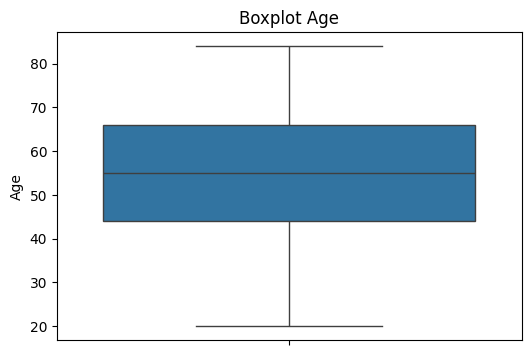

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df["Age"])

plt.title("Boxplot Age")
plt.show()

Analisis Univariant

Distribusi Target

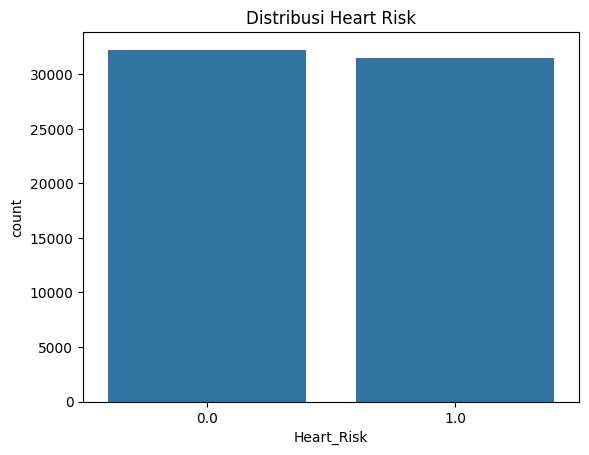

In [ ]:
sns.countplot(data=df,x="Heart_Risk")

plt.title("Distribusi Heart Risk")

plt.show()

Distribusi Umur

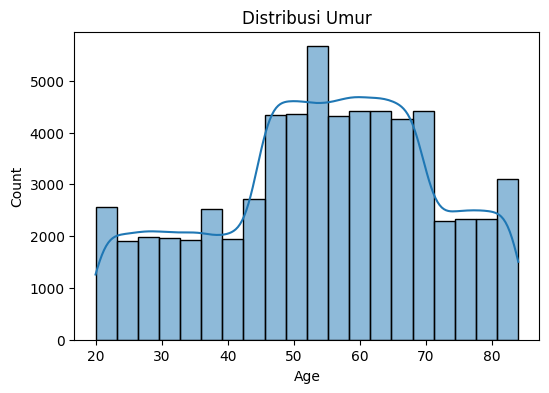

In [ ]:
plt.figure(figsize=(6,4))

sns.histplot(df["Age"],bins=20,kde=True)

plt.title("Distribusi Umur")

plt.show()

Distribusi seluruh variabel

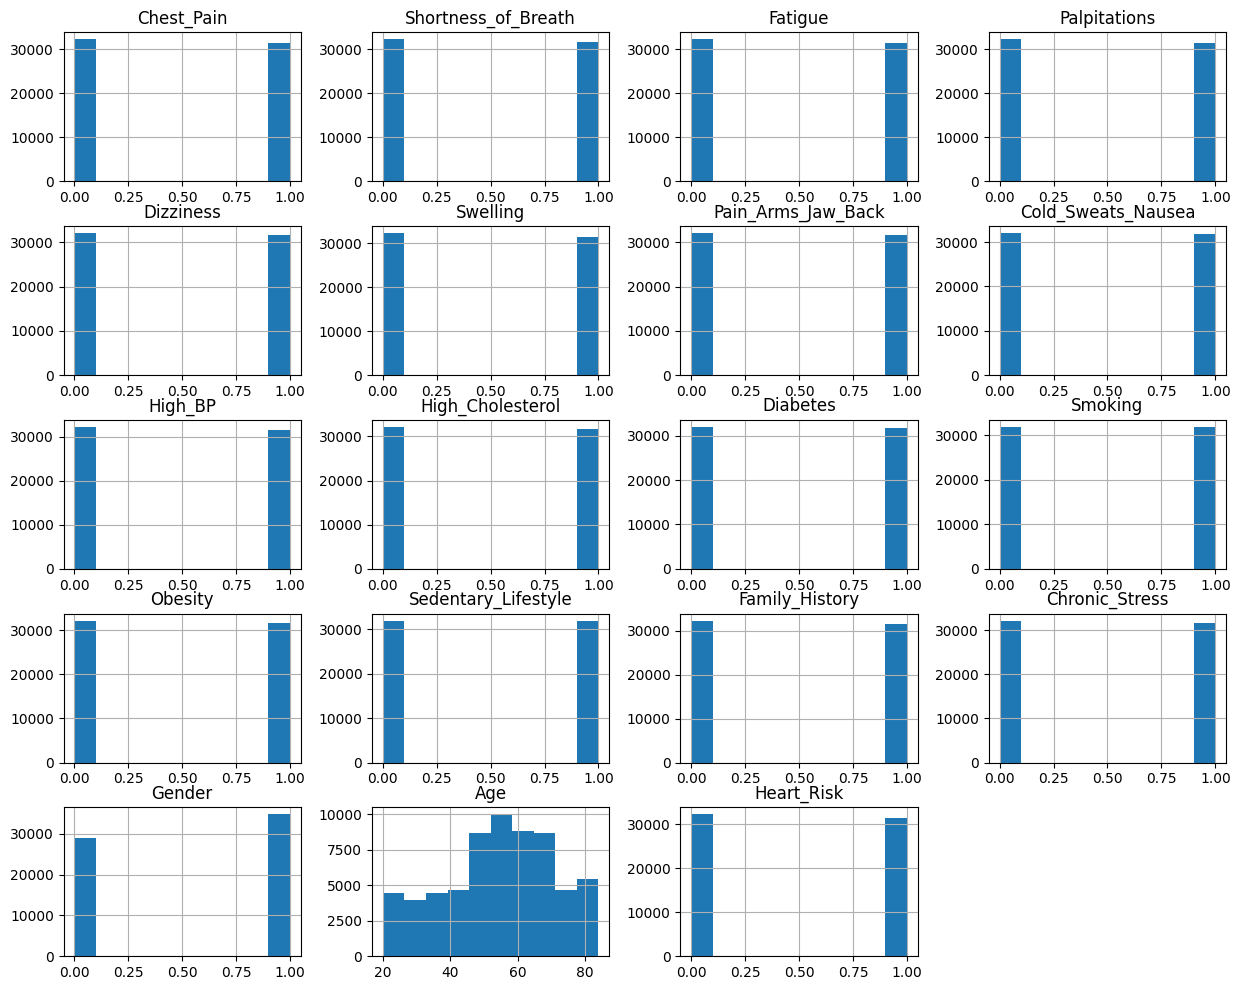

In [ ]:
df.hist(figsize=(15,12))

plt.show()

Analisis multivariant

Heatmap korelasi

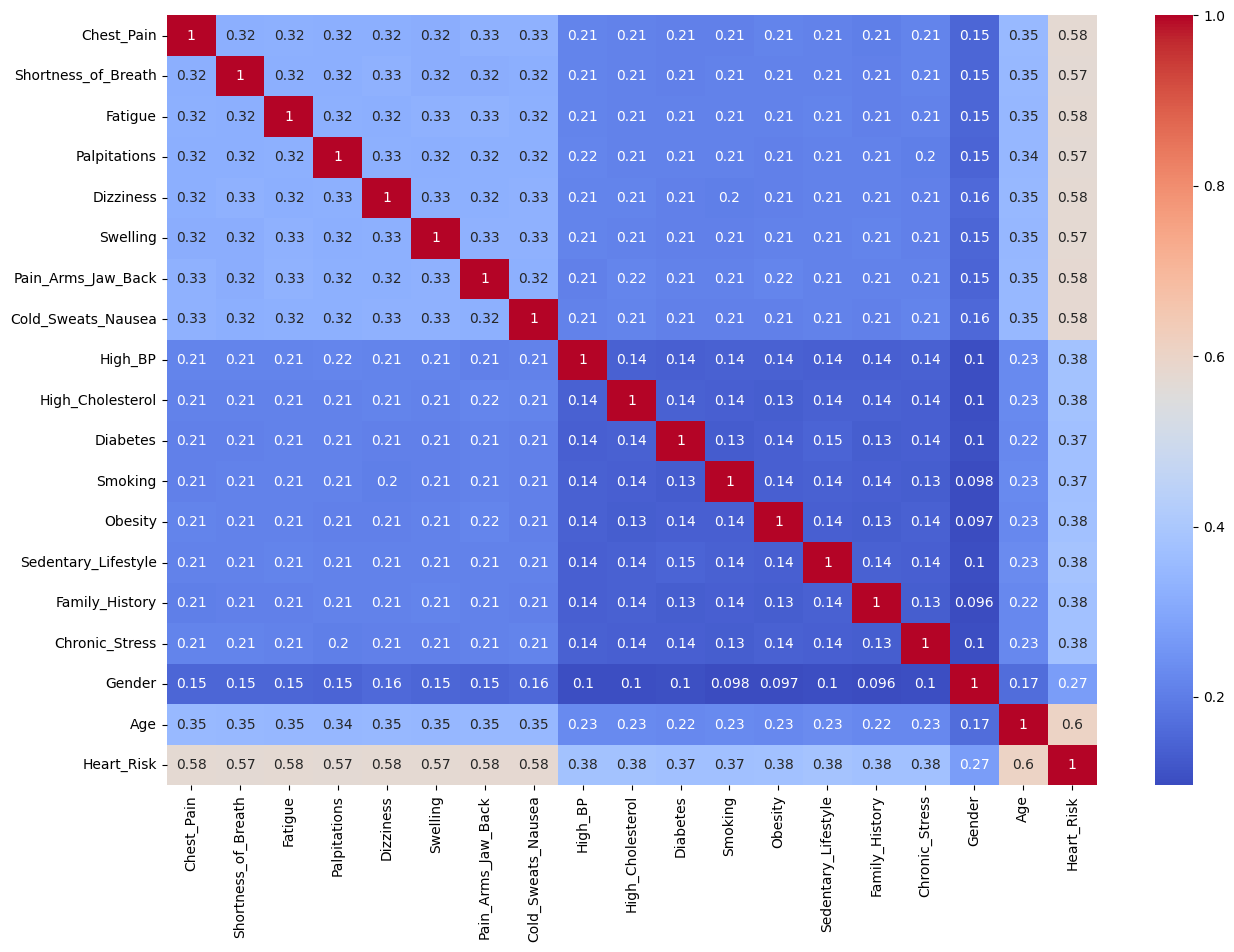

In [ ]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

Insight

Age cs Heart Risk

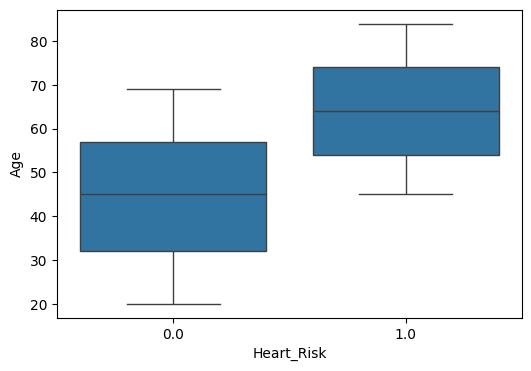

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Heart_Risk",
    y="Age"
)

plt.show()

**Insight:** Rata-rata usia pada kelompok berisiko tinggi (`Heart_Risk = 1`) adalah **~64 tahun**, jauh lebih tua dibanding kelompok risiko rendah (**~45 tahun**). Age memiliki korelasi tertinggi terhadap `Heart_Risk` (r ≈ 0.60) di antara seluruh fitur, menjadikannya prediktor tunggal paling kuat dalam dataset ini.

High Blood Pressure

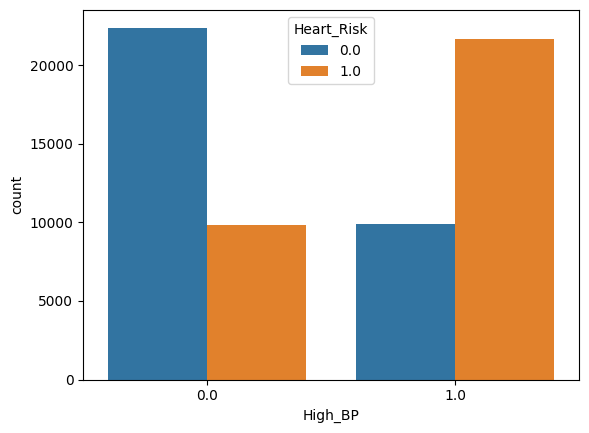

In [ ]:
sns.countplot(
    data=df,
    x="High_BP",
    hue="Heart_Risk"
)

plt.show()

**Insight:** Individu dengan `High_BP = 1` memiliki proporsi `Heart_Risk = 1` sebesar **68.6%**, jauh lebih tinggi dibanding individu tanpa tekanan darah tinggi (**30.6%**). Ini konsisten dengan literatur medis yang menempatkan hipertensi sebagai faktor risiko utama penyakit jantung.

Diabetes

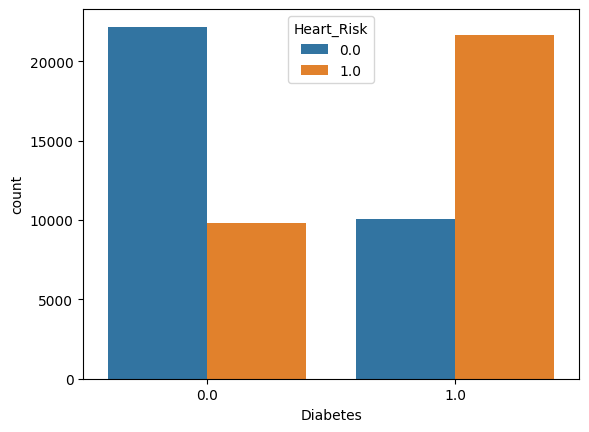

In [ ]:
sns.countplot(
    data=df,
    x="Diabetes",
    hue="Heart_Risk"
)

plt.show()

**Insight:** Pola serupa terlihat pada Diabetes — proporsi `Heart_Risk = 1` naik dari **30.7%** (tanpa diabetes) menjadi **68.2%** (dengan diabetes), menunjukkan diabetes juga berasosiasi kuat dengan risiko jantung dalam dataset ini.

Smoking

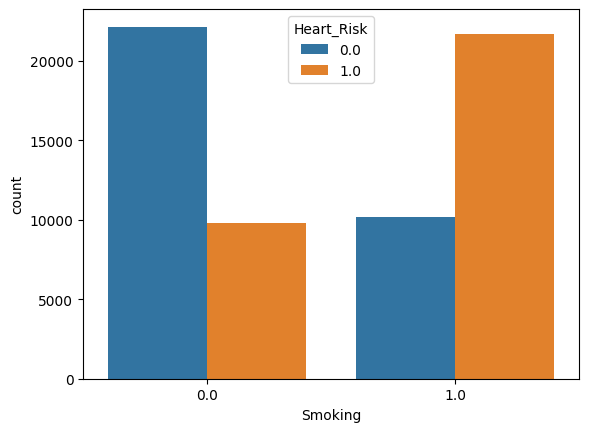

In [ ]:
sns.countplot(
    data=df,
    x="Smoking",
    hue="Heart_Risk"
)

plt.show()

**Insight:** Perokok (`Smoking = 1`) menunjukkan proporsi risiko tinggi **68.2%** dibanding **30.7%** pada bukan perokok — mengonfirmasi merokok sebagai salah satu faktor risiko gaya hidup yang signifikan.

Obesity

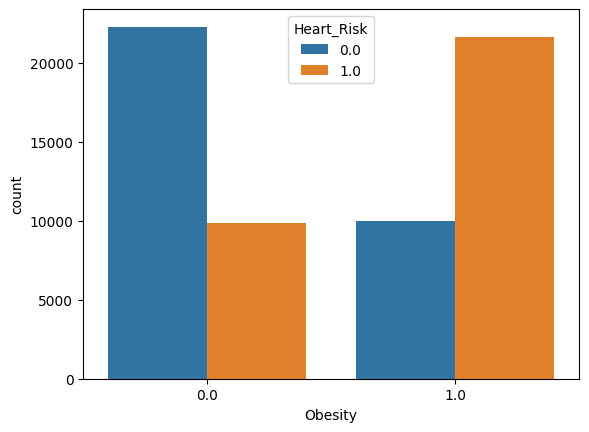

In [ ]:
sns.countplot(
    data=df,
    x="Obesity",
    hue="Heart_Risk"
)

plt.show()

**Insight:** Obesitas menunjukkan pola yang sama — **68.4%** individu obesitas berada pada kelompok risiko tinggi, dibanding **30.7%** pada individu non-obesitas. Secara keseluruhan, kelima insight ini (Age, High_BP, Diabetes, Smoking, Obesity) menunjukkan bahwa **kombinasi usia lanjut + gejala klinis + faktor gaya hidup** secara konsisten berasosiasi dengan risiko jantung yang lebih tinggi, dan seluruh fitur gejala klinis (Chest_Pain, Fatigue, dll.) bahkan memiliki korelasi lebih tinggi (r ≈ 0.57) dibanding faktor gaya hidup (r ≈ 0.37-0.38) terhadap target.

Data Preparation

In [ ]:
X = df.drop("Heart_Risk",axis=1)

y = df["Heart_Risk"]

Train Validation Test Split

In [ ]:
X_train,X_temp,y_train,y_temp=train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val,X_test,y_val,y_test=train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

Missing Value

In [ ]:
imputer = SimpleImputer(strategy="mean")

# PENTING: fit HANYA pada data train untuk mencegah data leakage,
# lalu transform ke train/val/test menggunakan imputer yang sama
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)
X_val = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

Scaling

In [ ]:
scaler = StandardScaler()

# PENTING: fit HANYA pada X_train["Age"], lalu transform ke val/test
# dengan scaler yang sama (mencegah data leakage)
X_train["Age"] = scaler.fit_transform(X_train[["Age"]])
X_val["Age"] = scaler.transform(X_val[["Age"]])
X_test["Age"] = scaler.transform(X_test[["Age"]])

Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Gunakan SelectKBest dengan f_classif, fit HANYA pada X_train (mencegah data leakage)
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "F-Score": selector.scores_
}).sort_values(by="F-Score", ascending=False)

feature_scores

**Insight & Keputusan Feature Selection:** Skor F-statistic menunjukkan bahwa seluruh fitur memiliki hubungan yang signifikan secara statistik dengan `Heart_Risk` (tidak ada F-Score yang mendekati nol). Fitur gejala klinis (Chest_Pain, Fatigue, Cold_Sweats_Nausea, dsb.) dan `Age` memiliki skor tertinggi, sedangkan `Gender` memiliki skor terendah namun tetap kontributif. Karena jumlah fitur relatif sedikit (18 fitur) dan tidak ada fitur yang benar-benar tidak relevan/redundan, **keputusan yang diambil adalah mempertahankan seluruh fitur** untuk tahap modeling, alih-alih membuang fitur yang berpotensi tetap memberi sinyal prediktif tambahan bagi model ensemble seperti Random Forest.

Membuat Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

rf = RandomForestClassifier(random_state=42)

knn = KNeighborsClassifier(n_neighbors=5)

Training

In [ ]:
dt.fit(X_train,y_train)

rf.fit(X_train,y_train)

knn.fit(X_train,y_train)

KNeighborsClassifier()

Prediksi

In [ ]:
dt_pred = dt.predict(X_test)

rf_pred = rf.predict(X_test)

knn_pred = knn.predict(X_test)

Evaluasi

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

Tabel perbandingan

In [ ]:
hasil=[]

models={
    "Decision Tree":dt_pred,
    "Random Forest":rf_pred,
    "KNN":knn_pred
}

for nama,pred in models.items():

    hasil.append({
        "Model":nama,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1 Score":f1_score(y_test,pred)
    })

hasil=pd.DataFrame(hasil)

hasil

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.977520,0.977745,0.976710,0.977227
1,Random Forest,0.991635,0.989871,0.993225,0.991545
2,KNN,0.989230,0.988579,0.989625,0.989102


Classification report

In [ ]:
for nama,pred in models.items():

    print("="*60)

    print(nama)

    print(classification_report(y_test,pred))

Decision Tree
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      4841
         1.0       0.98      0.98      0.98      4723

    accuracy                           0.98      9564
   macro avg       0.98      0.98      0.98      9564
weighted avg       0.98      0.98      0.98      9564

Random Forest
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      4841
         1.0       0.99      0.99      0.99      4723

    accuracy                           0.99      9564
   macro avg       0.99      0.99      0.99      9564
weighted avg       0.99      0.99      0.99      9564

KNN
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      4841
         1.0       0.99      0.99      0.99      4723

    accuracy                           0.99      9564
   macro avg       0.99      0.99      0.99      9564
weighted avg       0.99      0.99      0.9

Confusion Matrix

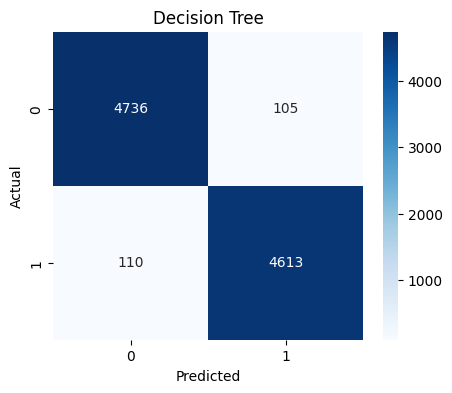

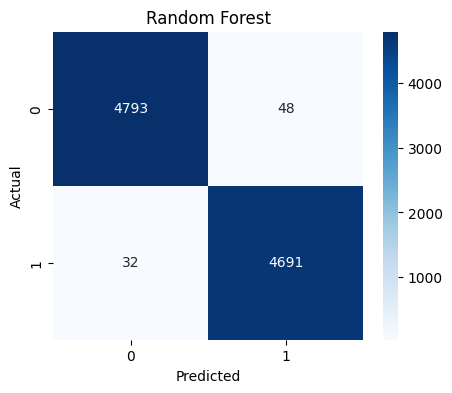

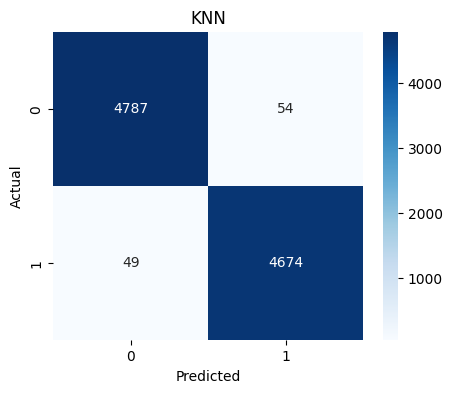

In [ ]:
for nama,pred in models.items():

    cm=confusion_matrix(y_test,pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues")

    plt.title(nama)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

Kesimpulan Model terbaik

In [ ]:
hasil.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.991635,0.989871,0.993225,0.991545
2,KNN,0.989230,0.988579,0.989625,0.989102
0,Decision Tree,0.977520,0.977745,0.976710,0.977227


**Interpretasi & Justifikasi Model Terbaik:**

Berdasarkan tabel perbandingan di atas, **Random Forest** terpilih sebagai model terbaik dengan performa tertinggi di semua metrik (Accuracy ≈ 99.16%, Precision ≈ 98.99%, **Recall ≈ 99.32%**, F1-Score ≈ 99.15%). Beberapa alasan Random Forest unggul dibanding Decision Tree dan KNN:

1. **Recall tertinggi** — sesuai prioritas metrik kesuksesan proyek ini (lihat Soal 1), Random Forest paling minim menghasilkan *false negative* (pasien berisiko tinggi yang salah diprediksi rendah risiko), yang paling krusial dalam konteks skrining medis.
2. **Ensemble mengurangi overfitting** — sebagai gabungan banyak decision tree dengan voting, Random Forest lebih stabil dan tidak terlalu bergantung pada satu struktur pohon tunggal seperti Decision Tree tunggal, sehingga generalisasinya ke data uji lebih baik.
3. **Menangani kombinasi fitur biner + kontinu dengan baik** — cocok dengan struktur dataset ini (17 fitur biner + `Age` kontinu) tanpa perlu asumsi distribusi tertentu, berbeda dengan KNN yang sensitif terhadap skala dan curse of dimensionality.

**Catatan penting:** Akurasi di atas 97% pada ketiga model sekaligus mengindikasikan dataset ini memiliki pola yang sangat konsisten — kemungkinan besar karena sifatnya yang **sintetis** (lihat catatan limitasi di Soal 1). Performa setinggi ini kemungkinan tidak akan tercapai apabila model diterapkan pada data rekam medis riil yang lebih *noisy* dan memiliki lebih banyak faktor perancu (*confounding factors*). Hal ini perlu disampaikan secara transparan dalam laporan akhir sebagai batasan proyek.